In [1]:
#!/usr/bin/env python3

# Menyesuaikan path agar dapat mengimpor modul dari direktori utama (induk)
# tanpa mengubah struktur direktori proyek
import sys
sys.path.append('..')

# Mengimpor file module untuk melakukan sync semua file
# pada direktori utama (induk)
import module

In [2]:
import os
from pathlib import Path


# Sumber utama dataset CASME
BASE_CASME_DATASET_PATH = os.path.join(Path.home(), "datasets", "secondaries", "casme-2")

# Memastikan direktori dataset CASME ada
assert os.path.exists(BASE_CASME_DATASET_PATH), f"Dataset CASME tidak ditemukan di {BASE_CASME_DATASET_PATH}"

# Memastikan anotasi CASME ada
ANNOTATIONS_CASME_PATH = os.path.join(BASE_CASME_DATASET_PATH, "annotations.xlsx")

# Memastikan file anotasi CASME ada
assert os.path.exists(ANNOTATIONS_CASME_PATH), f"Anotasi CASME tidak ditemukan di {ANNOTATIONS_CASME_PATH}"

print("Datasource set successfully.")

Datasource set successfully.


In [3]:
import os
import glob


# Mendefinisikan path untuk cerita temporal subject 001
SUB_001_EP02_01F = os.path.join(BASE_CASME_DATASET_PATH, "sub01", "EP02_01f")

# Mendapatkan semua file dalam cerita temporal 006_1_2
SUB_001_EP02_FILES = glob.glob(os.path.join(SUB_001_EP02_01F, "*"))

# Mendefinisikan path untuk cerita temporal 006_1_3
SUB_001_EP03_02 = os.path.join(BASE_CASME_DATASET_PATH, "sub01", "EP03_02")

# Mendapatkan semua file dalam cerita temporal 006_1_3
SUB_001_EP03_FILES = glob.glob(os.path.join(SUB_001_EP03_02, "*"))

# Memastikan ada file yang ditemukan dalam cerita temporal 006_1_2
assert len(SUB_001_EP02_FILES) > 0, f"Tidak ada file ditemukan di {SUB_001_EP02_01F}"

assert len(SUB_001_EP03_FILES) > 0, f"Tidak ada file ditemukan di {SUB_001_EP03_02}"

print("Temporal sample files found successfully.")

Temporal sample files found successfully.


W0000 00:00:1770341336.956388   14520 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1770341336.962569   14524 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770341336.972755   14524 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


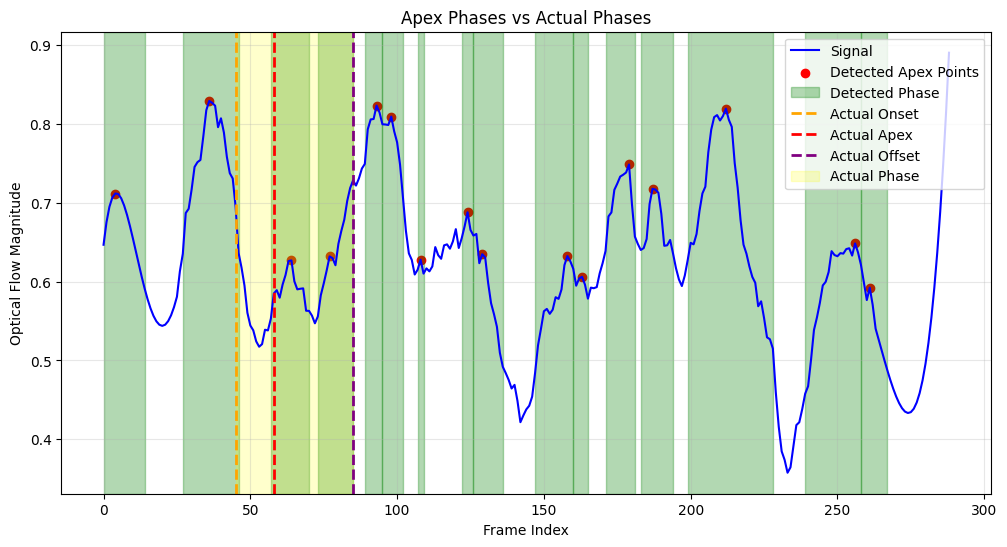

In [ ]:
import cv2
import numpy as np
from scipy.signal import savgol_filter
from src.face.modules import FaceLandmark
from src.apex.modules import ApexPhase, ApexSmoother, ApexPhaseVisualizer
from src.optical_flow.modules import TVL1


magnitudes = []

face_landmark = FaceLandmark()

tvl1 = TVL1()

for i in range(len(SUB_001_EP02_FILES) - 1):
    
    prev_frame = cv2.imread(SUB_001_EP02_FILES[i])
    next_frame = cv2.imread(SUB_001_EP02_FILES[i + 1])

    prev_landmarks = face_landmark.detect(prev_frame)
    next_landmarks = face_landmark.detect(next_frame)

    prev_face = face_landmark.crop(image=prev_frame, landmarks=prev_landmarks)
    next_face = face_landmark.crop(image=next_frame, landmarks=next_landmarks)

    flow = tvl1.compute(prev_face, next_face)

    dx = flow[..., 0]
    dy = flow[..., 1]

    magnitude = np.sqrt(dx**2 + dy**2)

    mean_magnitude = np.mean(magnitude)

    magnitudes.append(mean_magnitude)


window_length = ApexSmoother.calculate_window_length(len(magnitudes))

polyorder = ApexSmoother.calculate_polyorder(window_length)

smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_phase = ApexPhase()

apexs = apex_phase.find_apex(signal=smoothed_magnitudes)
phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apexs)

actual_phases = dict(onset=45, apex=58, offset=85)

apex_phase_visualizer = ApexPhaseVisualizer()

apex_phase_visualizer.plot_phases_with_actual(signal=smoothed_magnitudes, 
                                              apex_indices=apexs, 
                                              phases=phases,
                                              actual_phases=actual_phases)

W0000 00:00:1770341424.537760   14634 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1770341424.542138   14637 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770341424.552212   14635 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


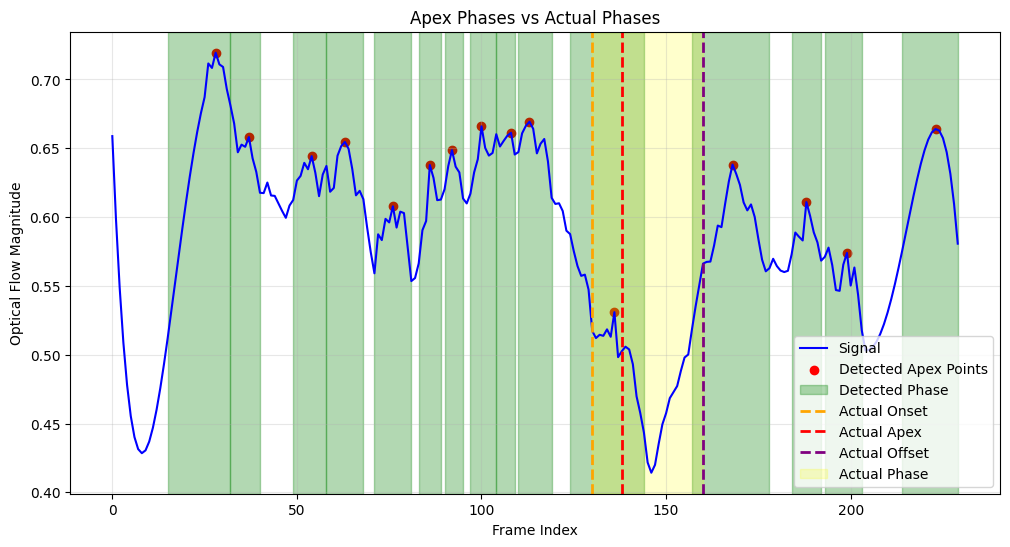

In [ ]:
import cv2
import numpy as np
from scipy.signal import savgol_filter
from src.face.modules import FaceLandmark
from src.apex.modules import ApexPhase, ApexSmoother, ApexPhaseVisualizer
from src.optical_flow.modules import TVL1


magnitudes = []

face_landmark = FaceLandmark()

tvl1 = TVL1()

for i in range(len(SUB_001_EP03_FILES) - 1):
    
    prev_frame = cv2.imread(SUB_001_EP03_FILES[i])
    next_frame = cv2.imread(SUB_001_EP03_FILES[i + 1])

    prev_landmarks = face_landmark.detect(prev_frame)
    next_landmarks = face_landmark.detect(next_frame)

    prev_face = face_landmark.crop(image=prev_frame, landmarks=prev_landmarks)
    next_face = face_landmark.crop(image=next_frame, landmarks=next_landmarks)

    flow = tvl1.compute(prev_face, next_face)

    dx = flow[..., 0]
    dy = flow[..., 1]

    magnitude = np.sqrt(dx**2 + dy**2)

    mean_magnitude = np.mean(magnitude)

    magnitudes.append(mean_magnitude)


window_length = ApexSmoother.calculate_window_length(len(magnitudes))

polyorder = ApexSmoother.calculate_polyorder(window_length)

smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_phase = ApexPhase()

apexs = apex_phase.find_apex(signal=smoothed_magnitudes)
phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apexs)

actual_phases = dict(onset=130, apex=138, offset=160)

apex_phase_visualizer = ApexPhaseVisualizer()

apex_phase_visualizer.plot_phases_with_actual(signal=smoothed_magnitudes, 
                                              apex_indices=apexs, 
                                              phases=phases,
                                              actual_phases=actual_phases)

Menghitung nilai magnitudo berdasarkan region of interests

W0000 00:00:1770360180.260064   58427 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1770360180.284842   58434 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770360180.305922   58443 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


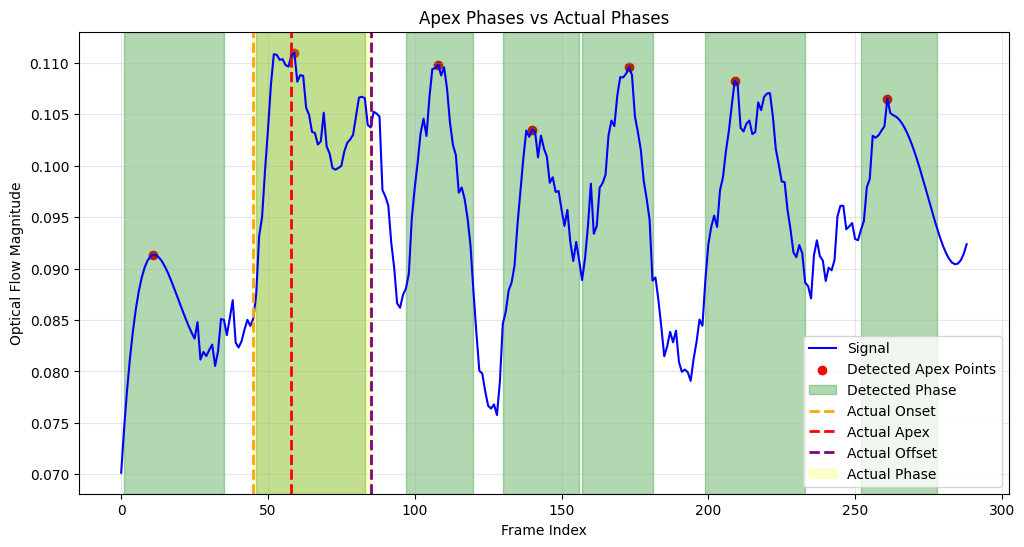

In [7]:
import cv2
import numpy as np
from src.face.modules import FaceLandmark, FaceRoiPoints, FaceRoiSizes
from src.apex.modules import ApexPhase, ApexPhaseVisualizer
from src.optical_flow.modules import TVL1


face_landmark = FaceLandmark()

tvl1 = TVL1()

magnitudes = []

for i in range(len(SUB_001_EP02_FILES) - 1):

    prev_frame = cv2.imread(SUB_001_EP02_FILES[i])
    next_frame = cv2.imread(SUB_001_EP02_FILES[i + 1])

    prev_landmarks = face_landmark.detect(prev_frame)
    next_landmarks = face_landmark.detect(next_frame)

    cropped_left_eye_prev, left_eye_roi_mask               = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_left_eye_next, left_eye_roi_mask               = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_right_eye_prev, right_eye_roi_mask             = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_right_eye_next, right_eye_roi_mask             = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_left_eyebrow_prev, left_eyebrow_roi_mask       = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)
    
    cropped_left_eyebrow_next, left_eyebrow_roi_mask       = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)
    
    cropped_right_eyebrow_prev, right_eyebrow_roi_mask     = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)
    
    cropped_right_eyebrow_next, right_eyebrow_roi_mask     = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)

    cropped_lips_prev, lips_roi_mask                       = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.LIPS_POINTS,
                                                                                    target_size=FaceRoiSizes.LIPS_SIZE)
    
    cropped_lips_next, lips_roi_mask                       = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.LIPS_POINTS,
                                                                                    target_size=FaceRoiSizes.LIPS_SIZE)
    

    flow_left_eye           = tvl1.compute(cropped_left_eye_prev, cropped_left_eye_next)
    flow_right_eye          = tvl1.compute(cropped_right_eye_prev, cropped_right_eye_next)
    flow_left_eyebrow       = tvl1.compute(cropped_left_eyebrow_prev, cropped_left_eyebrow_next)
    flow_right_eyebrow      = tvl1.compute(cropped_right_eyebrow_prev, cropped_right_eyebrow_next)
    flow_lips               = tvl1.compute(cropped_lips_prev, cropped_lips_next)

    flow_left_eye[..., 0]    *= (left_eye_roi_mask > 0)
    flow_left_eye[..., 1]    *= (left_eye_roi_mask > 0)

    flow_right_eye[..., 0]   *= (right_eye_roi_mask > 0)
    flow_right_eye[..., 1]   *= (right_eye_roi_mask > 0)

    flow_left_eyebrow[..., 0]    *= (left_eyebrow_roi_mask > 0)
    flow_left_eyebrow[..., 1]    *= (left_eyebrow_roi_mask > 0)

    flow_right_eyebrow[..., 0]   *= (right_eyebrow_roi_mask > 0)
    flow_right_eyebrow[..., 1]   *= (right_eyebrow_roi_mask > 0)

    flow_lips[..., 0]    *= (lips_roi_mask > 0)
    flow_lips[..., 1]    *= (lips_roi_mask > 0)

    magnitude_left_eye          = np.sqrt(flow_left_eye[..., 0]**2 + flow_left_eye[..., 1]**2)
    magnitude_right_eye         = np.sqrt(flow_right_eye[..., 0]**2 + flow_right_eye[..., 1]**2)
    magnitude_left_eyebrow      = np.sqrt(flow_left_eyebrow[..., 0]**2 + flow_left_eyebrow[..., 1]**2)
    magnitude_right_eyebrow     = np.sqrt(flow_right_eyebrow[..., 0]**2 + flow_right_eyebrow[..., 1]**2)
    magnitude_lips              = np.sqrt(flow_lips[..., 0]**2 + flow_lips[..., 1]**2)

    mean_magnitude_left_eye        = np.mean(magnitude_left_eye)
    mean_magnitude_right_eye       = np.mean(magnitude_right_eye)
    mean_magnitude_left_eyebrow    = np.mean(magnitude_left_eyebrow)
    mean_magnitude_right_eyebrow   = np.mean(magnitude_right_eyebrow)
    mean_magnitude_lips            = np.mean(magnitude_lips)

    mean_magnitude = np.mean([
        mean_magnitude_left_eye,
        mean_magnitude_right_eye,
        mean_magnitude_left_eyebrow,
        mean_magnitude_right_eyebrow,
        mean_magnitude_lips
    ])

    magnitudes.append(mean_magnitude)


window_length = ApexSmoother.calculate_window_length(len(magnitudes))

polyorder = ApexSmoother.calculate_polyorder(window_length)

smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_phase = ApexPhase()

apexs = apex_phase.find_apex(signal=smoothed_magnitudes)
phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apexs)

actual_phases = dict(onset=45, apex=58, offset=85)

apex_phase_visualizer = ApexPhaseVisualizer()

apex_phase_visualizer.plot_phases_with_actual(signal=smoothed_magnitudes, 
                                              apex_indices=apexs, 
                                              phases=phases,
                                              actual_phases=actual_phases)

W0000 00:00:1770360346.547164   60193 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1770360346.553518   60197 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770360346.565445   60197 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


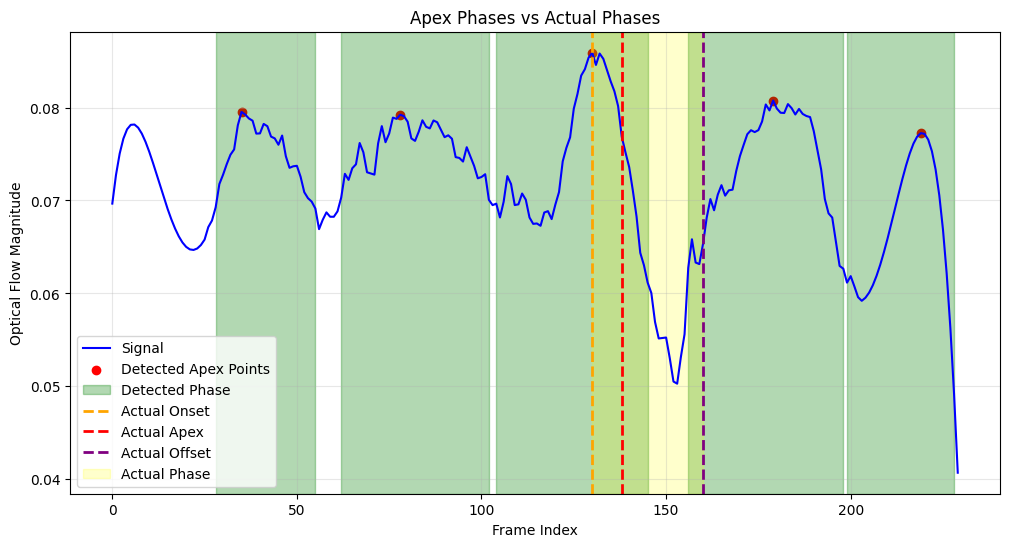

In [9]:
import cv2
import numpy as np
from src.face.modules import FaceLandmark, FaceRoiPoints, FaceRoiSizes
from src.apex.modules import ApexPhase, ApexPhaseVisualizer
from src.optical_flow.modules import TVL1


face_landmark = FaceLandmark()

tvl1 = TVL1()

magnitudes = []

for i in range(len(SUB_001_EP03_FILES) - 1):

    prev_frame = cv2.imread(SUB_001_EP03_FILES[i])
    next_frame = cv2.imread(SUB_001_EP03_FILES[i + 1])

    prev_landmarks = face_landmark.detect(prev_frame)
    next_landmarks = face_landmark.detect(next_frame)

    cropped_left_eye_prev, left_eye_roi_mask               = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_left_eye_next, left_eye_roi_mask               = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_right_eye_prev, right_eye_roi_mask             = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_right_eye_next, right_eye_roi_mask             = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_left_eyebrow_prev, left_eyebrow_roi_mask       = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)
    
    cropped_left_eyebrow_next, left_eyebrow_roi_mask       = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)
    
    cropped_right_eyebrow_prev, right_eyebrow_roi_mask     = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)
    
    cropped_right_eyebrow_next, right_eyebrow_roi_mask     = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)

    cropped_lips_prev, lips_roi_mask                       = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.LIPS_POINTS,
                                                                                    target_size=FaceRoiSizes.LIPS_SIZE)
    
    cropped_lips_next, lips_roi_mask                       = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.LIPS_POINTS,
                                                                                    target_size=FaceRoiSizes.LIPS_SIZE)
    

    flow_left_eye           = tvl1.compute(cropped_left_eye_prev, cropped_left_eye_next)
    flow_right_eye          = tvl1.compute(cropped_right_eye_prev, cropped_right_eye_next)
    flow_left_eyebrow       = tvl1.compute(cropped_left_eyebrow_prev, cropped_left_eyebrow_next)
    flow_right_eyebrow      = tvl1.compute(cropped_right_eyebrow_prev, cropped_right_eyebrow_next)
    flow_lips               = tvl1.compute(cropped_lips_prev, cropped_lips_next)

    flow_left_eye[..., 0]    *= (left_eye_roi_mask > 0)
    flow_left_eye[..., 1]    *= (left_eye_roi_mask > 0)

    flow_right_eye[..., 0]   *= (right_eye_roi_mask > 0)
    flow_right_eye[..., 1]   *= (right_eye_roi_mask > 0)

    flow_left_eyebrow[..., 0]    *= (left_eyebrow_roi_mask > 0)
    flow_left_eyebrow[..., 1]    *= (left_eyebrow_roi_mask > 0)

    flow_right_eyebrow[..., 0]   *= (right_eyebrow_roi_mask > 0)
    flow_right_eyebrow[..., 1]   *= (right_eyebrow_roi_mask > 0)

    flow_lips[..., 0]    *= (lips_roi_mask > 0)
    flow_lips[..., 1]    *= (lips_roi_mask > 0)

    magnitude_left_eye          = np.sqrt(flow_left_eye[..., 0]**2 + flow_left_eye[..., 1]**2)
    magnitude_right_eye         = np.sqrt(flow_right_eye[..., 0]**2 + flow_right_eye[..., 1]**2)
    magnitude_left_eyebrow      = np.sqrt(flow_left_eyebrow[..., 0]**2 + flow_left_eyebrow[..., 1]**2)
    magnitude_right_eyebrow     = np.sqrt(flow_right_eyebrow[..., 0]**2 + flow_right_eyebrow[..., 1]**2)
    magnitude_lips              = np.sqrt(flow_lips[..., 0]**2 + flow_lips[..., 1]**2)

    mean_magnitude_left_eye        = np.mean(magnitude_left_eye)
    mean_magnitude_right_eye       = np.mean(magnitude_right_eye)
    mean_magnitude_left_eyebrow    = np.mean(magnitude_left_eyebrow)
    mean_magnitude_right_eyebrow   = np.mean(magnitude_right_eyebrow)
    mean_magnitude_lips            = np.mean(magnitude_lips)

    mean_magnitude = np.mean([
        mean_magnitude_left_eye,
        mean_magnitude_right_eye,
        mean_magnitude_left_eyebrow,
        mean_magnitude_right_eyebrow,
        mean_magnitude_lips
    ])

    magnitudes.append(mean_magnitude)


window_length = ApexSmoother.calculate_window_length(len(magnitudes))

polyorder = ApexSmoother.calculate_polyorder(window_length)

smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_phase = ApexPhase()

apexs = apex_phase.find_apex(signal=smoothed_magnitudes)
phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apexs)

actual_phases = dict(onset=130, apex=138, offset=160)

apex_phase_visualizer = ApexPhaseVisualizer()

apex_phase_visualizer.plot_phases_with_actual(signal=smoothed_magnitudes, 
                                              apex_indices=apexs, 
                                              phases=phases,
                                              actual_phases=actual_phases)

In [10]:
import os
import glob


# Mendefinisikan path untuk cerita temporal 006_1_3
SUB_001_EP04_02 = os.path.join(BASE_CASME_DATASET_PATH, "sub01", "EP04_02")

# Mendapatkan semua file dalam cerita temporal 006_1_3
SUB_001_EP04_FILES = glob.glob(os.path.join(SUB_001_EP04_02, "*"))

W0000 00:00:1770360509.531082   61478 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1770360509.546198   61481 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770360509.561379   61494 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


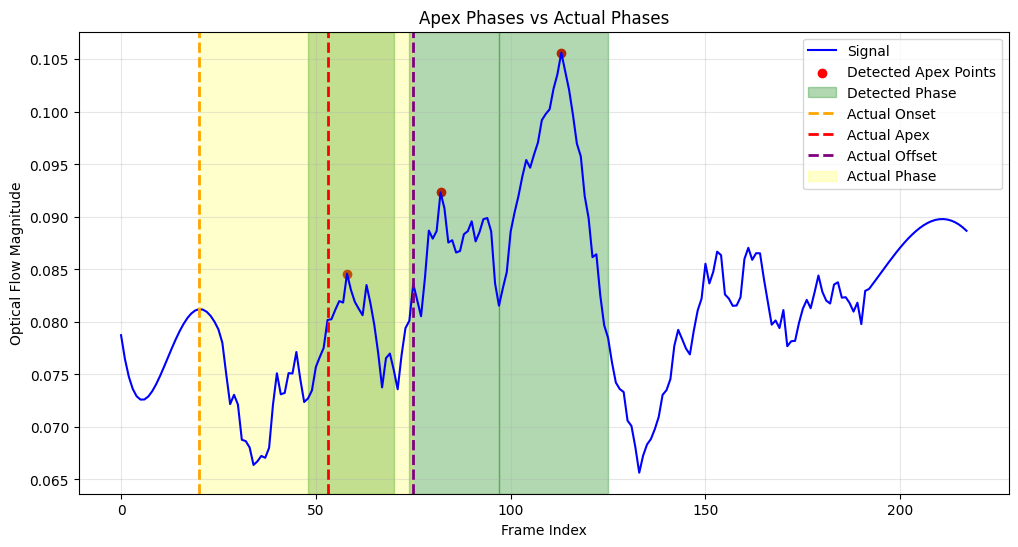

In [12]:
import cv2
import numpy as np
from src.face.modules import FaceLandmark, FaceRoiPoints, FaceRoiSizes
from src.apex.modules import ApexPhase, ApexPhaseVisualizer
from src.optical_flow.modules import TVL1


face_landmark = FaceLandmark()

tvl1 = TVL1()

magnitudes = []

for i in range(len(SUB_001_EP04_FILES) - 1):

    prev_frame = cv2.imread(SUB_001_EP04_FILES[i])
    next_frame = cv2.imread(SUB_001_EP04_FILES[i + 1])

    prev_landmarks = face_landmark.detect(prev_frame)
    next_landmarks = face_landmark.detect(next_frame)

    cropped_left_eye_prev, left_eye_roi_mask               = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_left_eye_next, left_eye_roi_mask               = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_right_eye_prev, right_eye_roi_mask             = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_right_eye_next, right_eye_roi_mask             = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_left_eyebrow_prev, left_eyebrow_roi_mask       = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)
    
    cropped_left_eyebrow_next, left_eyebrow_roi_mask       = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)
    
    cropped_right_eyebrow_prev, right_eyebrow_roi_mask     = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)
    
    cropped_right_eyebrow_next, right_eyebrow_roi_mask     = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)

    cropped_lips_prev, lips_roi_mask                       = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.LIPS_POINTS,
                                                                                    target_size=FaceRoiSizes.LIPS_SIZE)
    
    cropped_lips_next, lips_roi_mask                       = face_landmark.crop_roi(image=next_frame.copy(),
                                                                                    landmark_result=next_landmarks,
                                                                                    roi_points=FaceRoiPoints.LIPS_POINTS,
                                                                                    target_size=FaceRoiSizes.LIPS_SIZE)
    

    flow_left_eye           = tvl1.compute(cropped_left_eye_prev, cropped_left_eye_next)
    flow_right_eye          = tvl1.compute(cropped_right_eye_prev, cropped_right_eye_next)
    flow_left_eyebrow       = tvl1.compute(cropped_left_eyebrow_prev, cropped_left_eyebrow_next)
    flow_right_eyebrow      = tvl1.compute(cropped_right_eyebrow_prev, cropped_right_eyebrow_next)
    flow_lips               = tvl1.compute(cropped_lips_prev, cropped_lips_next)

    flow_left_eye[..., 0]    *= (left_eye_roi_mask > 0)
    flow_left_eye[..., 1]    *= (left_eye_roi_mask > 0)

    flow_right_eye[..., 0]   *= (right_eye_roi_mask > 0)
    flow_right_eye[..., 1]   *= (right_eye_roi_mask > 0)

    flow_left_eyebrow[..., 0]    *= (left_eyebrow_roi_mask > 0)
    flow_left_eyebrow[..., 1]    *= (left_eyebrow_roi_mask > 0)

    flow_right_eyebrow[..., 0]   *= (right_eyebrow_roi_mask > 0)
    flow_right_eyebrow[..., 1]   *= (right_eyebrow_roi_mask > 0)

    flow_lips[..., 0]    *= (lips_roi_mask > 0)
    flow_lips[..., 1]    *= (lips_roi_mask > 0)

    magnitude_left_eye          = np.sqrt(flow_left_eye[..., 0]**2 + flow_left_eye[..., 1]**2)
    magnitude_right_eye         = np.sqrt(flow_right_eye[..., 0]**2 + flow_right_eye[..., 1]**2)
    magnitude_left_eyebrow      = np.sqrt(flow_left_eyebrow[..., 0]**2 + flow_left_eyebrow[..., 1]**2)
    magnitude_right_eyebrow     = np.sqrt(flow_right_eyebrow[..., 0]**2 + flow_right_eyebrow[..., 1]**2)
    magnitude_lips              = np.sqrt(flow_lips[..., 0]**2 + flow_lips[..., 1]**2)

    mean_magnitude_left_eye        = np.mean(magnitude_left_eye)
    mean_magnitude_right_eye       = np.mean(magnitude_right_eye)
    mean_magnitude_left_eyebrow    = np.mean(magnitude_left_eyebrow)
    mean_magnitude_right_eyebrow   = np.mean(magnitude_right_eyebrow)
    mean_magnitude_lips            = np.mean(magnitude_lips)

    mean_magnitude = np.mean([
        mean_magnitude_left_eye,
        mean_magnitude_right_eye,
        mean_magnitude_left_eyebrow,
        mean_magnitude_right_eyebrow,
        mean_magnitude_lips
    ])

    magnitudes.append(mean_magnitude)


window_length = ApexSmoother.calculate_window_length(len(magnitudes))

polyorder = ApexSmoother.calculate_polyorder(window_length)

smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_phase = ApexPhase()

apexs = apex_phase.find_apex(signal=smoothed_magnitudes)
phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apexs)

actual_phases = dict(onset=20, apex=53, offset=75)

apex_phase_visualizer = ApexPhaseVisualizer()

apex_phase_visualizer.plot_phases_with_actual(signal=smoothed_magnitudes, 
                                              apex_indices=apexs, 
                                              phases=phases,
                                              actual_phases=actual_phases)